<a href="https://colab.research.google.com/github/Meenakrishnan-work/Meenakrishnan-work.github.io/blob/main/Churn_RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    roc_auc_score, roc_curve
)
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report

In [17]:
df = pd.read_csv("Telco-Customer-Churn.csv")

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [19]:
df["TotalCharges"] = df["TotalCharges"].str.strip().replace("", "0.0")
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0.0)
df["TotalCharges"] = df["TotalCharges"].astype(float)

In [20]:
# 3. Binary Yes/No and Male/Female columns → 0/1 with map (keeps single column, no dummy explosion)
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map(binary_map)

In [21]:
# 4. Multi-category columns → one-hot encoding
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
                   'OnlineBackup', 'DeviceProtection', 'TechSupport',
                   'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)
print(df.dtypes)

customerID                                object
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes

In [26]:
# Separate features and target
X = df.drop(columns=["Churn", "customerID"])  # drop ID cols too
y = df["Churn"] # encode if needed

In [24]:
print(y.isna().sum())

7043


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [31]:
print("X_train count:", X_train.shape)
print("y_train count:", y_train.shape)

print("X_test count:", X_test.shape)
print("y_test count:", y_test.shape)

X_train count: (5634, 30)
y_train count: (5634,)
X_test count: (1409, 30)
y_test count: (1409,)


In [29]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight="balanced",  # helps with imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [34]:
y_pred = rf.predict(X_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0])

In [41]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

In [42]:
print(f"Accuracy        : {accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 score        : {f1:.4f}")

Accuracy        : 0.7644
Precision        : 0.5396
Recall        : 0.7647
F1 score        : 0.6327


In [30]:
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.76      0.83      1035
           1       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.78      1409

ROC-AUC: 0.8441848149009274
[[791 244]
 [ 88 286]]


In [47]:
mse = mean_squared_error(y_test, y_prob)
mae = mean_absolute_error(y_test, y_prob)
rmse = np.sqrt(mse)
auc = roc_auc_score(y_test, y_prob)

print(f"MSE             : {mse:.4f}")
print(f"MAE             : {mae:.4f}")
print(f"RMSE            : {rmse:.4f}")
print(f"AUC             : {auc:.4f}")

MSE             : 0.1547
MAE             : 0.3083
RMSE            : 0.3933
AUC             : 0.8442


In [49]:
# Build comparison table
metrics_table = pd.DataFrame({
    "Metric": ["MSE", "MAE", "RMSE", "AUC"],
    "Model Value": [round(mse, 4), round(mae, 4), round(rmse, 4), round(auc, 4)],
    "Excellent": ["< 0.02", "< 0.10", "< 0.15", "> 0.90"],
    "Good": ["0.02 - 0.06", "0.10 - 0.20", "0.15 - 0.25", "0.80 - 0.90"],
    "Acceptable": ["0.06 - 0.15", "0.20 - 0.35", "0.25 - 0.40", "0.70 - 0.80"],
    "Poor": ["> 0.15", "> 0.35", "> 0.40", "< 0.70"]
})

In [50]:
# Status classifier
def get_status(metric, val):
    if metric == "AUC":
        if val > 0.90: return "Excellent"
        elif val > 0.80: return "Good"
        elif val > 0.70: return "Acceptable"
        else: return "Poor"
    thresholds = {
        "MSE":  [(0.02, "Excellent"), (0.06, "Good"), (0.15, "Acceptable")],
        "MAE":  [(0.10, "Excellent"), (0.20, "Good"), (0.35, "Acceptable")],
        "RMSE": [(0.15, "Excellent"), (0.25, "Good"), (0.40, "Acceptable")],
    }
    for limit, label in thresholds[metric]:
        if val < limit:
            return label
    return "Poor"

metrics_table["Status"] = [
    get_status("MSE", mse),
    get_status("MAE", mae),
    get_status("RMSE", rmse),
    get_status("AUC", auc)
]

# Color-code the Status column
def color_status(val):
    colors = {
        "Excellent": "background-color: #b7e4c7",
        "Good": "background-color: #d8f3dc",
        "Acceptable": "background-color: #fff3b0",
        "Poor": "background-color: #ffb3b3"
    }
    return colors.get(val, "")

styled_table = metrics_table.style.applymap(color_status, subset=["Status"])
styled_table

/tmp/ipykernel_804/4024722061.py:35: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_table = metrics_table.style.applymap(color_status, subset=["Status"])


,Metric,Model Value,Excellent,Good,Acceptable,Poor,Status
0,MSE,0.154700,< 0.02,0.02 - 0.06,0.06 - 0.15,> 0.15,Poor
1,MAE,0.308300,< 0.10,0.10 - 0.20,0.20 - 0.35,> 0.35,Acceptable
2,RMSE,0.393300,< 0.15,0.15 - 0.25,0.25 - 0.40,> 0.40,Acceptable
3,AUC,0.844200,> 0.90,0.80 - 0.90,0.70 - 0.80,< 0.70,Good


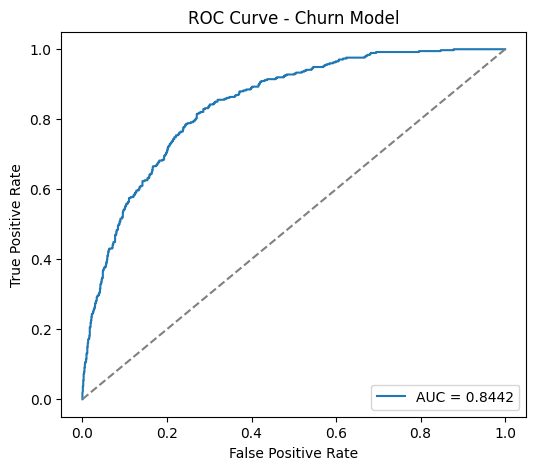

In [54]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Churn Model")
plt.legend(loc="lower right")
plt.show()